
### TODO for January 7th/2026: 

- [ ] Improve density fits with Colosus
- [x] Improve BFE density fits
- [ ] Plot basis density profiles
- [ ] Make time-dependent analysis
- [ ] 2D MIRSE density plots
- [ ] Make basis grids
- [ ] Enclosed mass at different radii between different combinations of particle classification
- [ ] Think about what it the length of the expansion needed. Perhaps using S/N?

### Questions. 
1. fuzz DM + oshs DM = total DM particles?
2. What about infalling DM particles?
3. Particle mass?
    - IllustrisTNG75 is TNG 100?
4. For Validation
    -  Compare density?
5. Best way to do this as a function of time.
6. Extrat the halo id.
7. Compute MISE in mass weighted bins in density or potential?

### Librarires
1. Useful to install the in virtual environments?
2. How hard is to set up hydrotools in a new simulation?

In [1]:
%matplotlib inline
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import splrep,  BSpline
from inspect import getmembers, isfunction
# EXP-related libraries 
import pyEXP
import EXPtools
# Cosmom sims
import colossus



In [202]:
# -------------------------
## Simulations parameters:
#--------------------------
DATAFILE = './galaxies_tng100-3_099.hdf5'
particle_mass = 3.2e8 # Msun TNG100-3

In [3]:
f = h5py.File(DATAFILE, 'r')
print(f.keys())

<KeysViewHDF5 ['catgrp_GroupCM', 'catgrp_GroupMassType', 'catgrp_GroupNsubs', 'catgrp_GroupPos', 'catgrp_GroupVel', 'catgrp_Group_M_Crit200', 'catgrp_Group_M_Crit500', 'catgrp_Group_M_Mean200', 'catgrp_Group_M_TopHat200', 'catgrp_Group_R_Crit200', 'catgrp_Group_R_Crit500', 'catgrp_Group_R_Mean200', 'catgrp_Group_R_TopHat200', 'catgrp_id', 'catgrp_is_primary', 'catsh_SubhaloCM', 'catsh_SubhaloGrNr', 'catsh_SubhaloHalfmassRadType', 'catsh_SubhaloMassInHalfRadType', 'catsh_SubhaloMassInRadType', 'catsh_SubhaloMassType', 'catsh_SubhaloPos', 'catsh_SubhaloSpin', 'catsh_SubhaloVel', 'catsh_SubhaloVmax', 'catsh_id', 'config', 'galaxy_015762_ptldm_Coordinates', 'galaxy_015762_ptldm_fuzz_Coordinates', 'galaxy_015762_ptldm_oshs_Coordinates', 'galaxy_016862_ptldm_Coordinates', 'galaxy_016862_ptldm_fuzz_Coordinates', 'galaxy_016862_ptldm_oshs_Coordinates', 'galaxy_016973_ptldm_Coordinates', 'galaxy_016973_ptldm_fuzz_Coordinates', 'galaxy_016973_ptldm_oshs_Coordinates', 'galaxy_018098_ptldm_Coordin

In [4]:
halos_particle_selection  = ['galaxy_016862_ptldm_Coordinates', 'galaxy_016862_ptldm_fuzz_Coordinates', 'galaxy_016862_ptldm_oshs_Coordinates']

Text(0.5, 1.0, 'Subhalo particles')

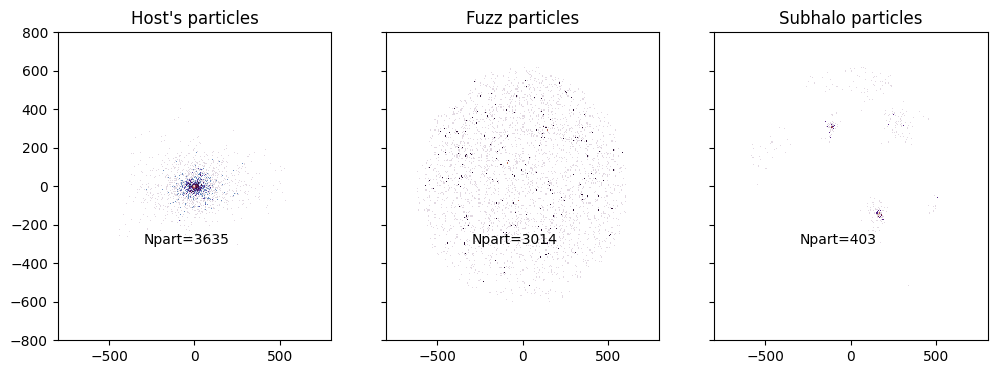

In [196]:
fig, ax = plt.subplots(1, 3, figsize=(12,4), sharey=True)

for i in range(3):
    pos = np.array(f[halos_particle_selection[i]])
    ax[i].text(-300, -300, 'Npart={}'.format(len(pos)))
    ax[i].hist2d(pos[:,0], pos[:,1], bins=200, norm=LogNorm(), cmap='twilight');
    ax[i].set_xlim(-800, 800)
    ax[i].set_ylim(-800, 800)

ax[0].set_title("Host's particles")
ax[1].set_title("Fuzz particles")
ax[2].set_title("Subhalo particles")

In [6]:
# get profiles from hydrotools 

In [7]:
def empirical_density_profile(rbins, pos, mass, smooth_length=0.0):
    """
    Computes the number density radial profile assuming all particles have the same mass.

    Args:
        pos (ndarray): array of particle positions in cartesian coordinates with shape (n,3).
        mass (ndarray): array of particle masses with shape (n,).
        nbins (int, optional): number of bins in the radial profile. Default is 500.
        rmin (float, optional): minimum radius of the radial profile. Default is 0.
        rmax (float, optional): maximum radius of the radial profile. Default is 600.
        log_space (bool, optional): whether to use logarithmic binning. Default is False.

    Returns:
        tuple: a tuple containing the arrays of radius and density with shapes (nbins,) and (nbins,), respectively.

    Raises:
        ValueError: if pos and mass arrays have different lengths or if nbins is not a positive integer.
    """
    if len(pos) != len(mass):
        raise ValueError("pos and mass arrays must have the same length")
    if not isinstance(len(rbins), int) or len(rbins) <= 0:
        raise ValueError("rbins must be a positive integer")

    # Compute radial distances
    r_p = np.sqrt(np.sum(pos**2, axis=1))

    V_shells = 4/3 * np.pi * (rbins[1:]**3 - rbins[:-1]**3)

    # Compute density profile
    density, _ = np.histogram(r_p, bins=rbins, weights=mass)
    density /= V_shells

    #compute bin centers and return profile
    radius = 0.5 * (rbins[1:] + rbins[:-1])

    if smooth_length != 0.0:
        tck_s = splrep(radius, np.log10(density), s=smooth_length)
        dens_smooth = BSpline(*tck_s)(radius)
        density = 10**dens_smooth
        
    return radius, density

In [ ]:
"""
Density profile grid
"""
nbins = 200
rmin = 0.01
rmax = 500
rbins = np.linspace(rmin, rmax, nbins+1)
rho_halo = np.zeros((3, nbins))

In [218]:
np.array(f[halos_particle_selection[0]]).
np.array(f[halos_particle_selection[1]])

array([[  74.70756141,  561.00237796, -184.67799487],
       [ 207.15238908,  559.30486461,  -88.52161214],
       [  84.13140195,  545.43337684, -195.68517788],
       ...,
       [ -16.85677176,  146.17582536, -377.18300953],
       [ 320.87367947, -174.15354348, -481.76955504],
       [-347.40996804, -220.26693637, -212.85764694]], shape=(3014, 3))

In [220]:
pos_host = np.array(f[halos_particle_selection[0]])
pos_host_fuzz = np.concatenate((np.array(f[halos_particle_selection[0]]), np.array(f[halos_particle_selection[1]])))
pos_all = np.concatenate((pos_host_fuzz, np.array(f[halos_particle_selection[2]])))

M_host = np.ones(len(pos_host))*particle_mass
M_host_fuzz = np.ones(len(pos_host_fuzz))*particle_mass
M_all = np.ones(len(pos_all))*particle_mass

r_halo, rho_host = empirical_density_profile(rbins, pos_host, mass=M_host)
r_halo, rho_host_fuzz = empirical_density_profile(rbins, pos_host_fuzz, mass=M_host_fuzz)
r_halo, rho_all = empirical_density_profile(rbins, pos_all, mass=M_all)

Text(0, 0.5, '$\\rho$')

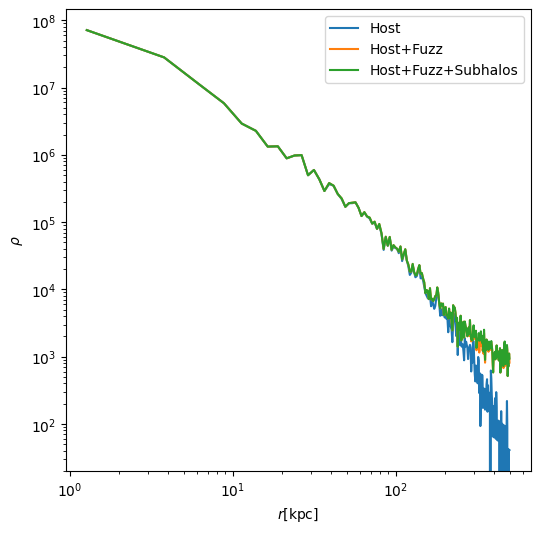

In [228]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), sharey=True)

ax.loglog(r_halo, rho_host, label="Host")
ax.loglog(r_halo, rho_host_fuzz, label='Host+Fuzz')
ax.loglog(r_halo, rho_all, label='Host+Fuzz+Subhalos')

ax.legend()
ax.set_xlabel(r'$r$[kpc]')
ax.set_ylabel(r'$\rho$')

# Get Halo properties using Colosus

In [229]:
from colossus.halo import mass_defs, concentration, profile_nfw, profile_einasto
from colossus.cosmology import cosmology
from colossus.halo import mass_so

In [230]:
"""
------------------
Halo parameters
------------------
"""
# Set Illustris TNG cosmology
cosmo = cosmology.setCosmology('planck15') 
redshift = 0.0
M200c = f['catgrp_Group_M_Crit200'][0]
R200c = f['catgrp_Group_R_Crit200'][0]
c200c = concentration.concentration(M200c, '200c', redshift)

# Transfrom to viriral quantities
Mvir, Rvir, cvir = mass_defs.changeMassDefinition(M200c, c200c, redshift, '200c', 'vir')

In [231]:
"""
NFW profile from halo finder
"""

p_nfw = profile_nfw.NFWProfile(M = Mvir, c = cvir, z = redshift, mdef = 'vir')
rho_m = cosmo.rho_m(redshift)
print("rho_m = ", rho_m)
## Important to have good sampling to ensurance a good basis fit! 
r_fit = np.logspace(-1, 2.8, 1000)
rho_nfw = p_nfw.density(r_fit)
for key in p_nfw.par.keys():
    print(key, p_nfw.par[key])

rho_m =  85.73106415619921
rhos 6263420.753786079
rs 25.719036283043625


In [232]:
"""
Einasto profile from halo finder
"""

p_einasto = profile_einasto.EinastoProfile(M=Mvir, c=cvir, z=redshift, mdef='vir')
rho_einasto = p_einasto.density(r_fit)
for key in p_einasto.par.keys():
    print(key, p_einasto.par[key])

rhos 1429085.16957809
rs 25.719036283043625
alpha 0.16242630665846344


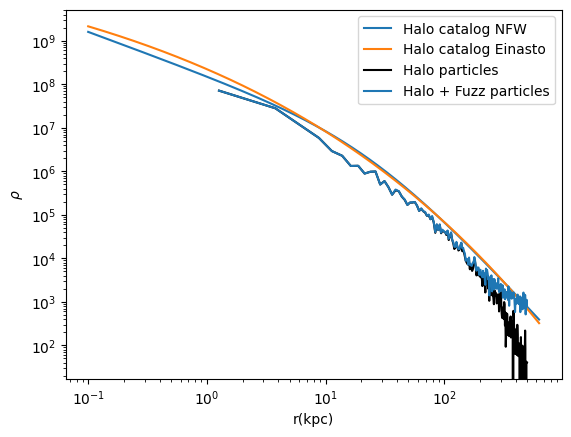

In [237]:
plt.figure()
plt.loglog()
plt.xlabel('r(kpc)')
plt.ylabel(r'$\rho$')
plt.plot(r_fit, rho_nfw, '-', label = 'Halo catalog NFW');
plt.plot(r_fit, rho_einasto, '-', label = 'Halo catalog Einasto');
plt.plot(r_halo, rho_host, c='k', label='Halo particles')
plt.plot(r_halo, rho_host_fuzz, c='C0', label='Halo + Fuzz particles')

plt.legend();

In [238]:
# Check enclosed mass

In [ ]:
plt.plot(einasto_model[:,0], einasto_model[:,2])
plt.plot(nfw_model[:,0], nfw_model[:,2])

plt.axhline(Mvir, label='Mvir', c='C0', ls='--')
plt.axhline(Mtot, label='Mtot', c='C1', ls='--')
plt.axvline(Rvir, label='Rvir', c='C0', ls=':')
plt.legend()

In [159]:
# --------------------
# Einasto profile Fit
# --------------------

fit_mask = np.array([True, True, True])
x_true = p_einasto.getParameterArray(fit_mask)
ini_guess = x_true
print(ini_guess)
p_einasto.setParameterArray(ini_guess, mask = fit_mask)
dic = p_einasto.fit(r_halo, rho_halo, 'rho', mask = fit_mask, method='leastsq')


[1.42908517e+06 2.57190363e+01 1.62426307e-01]
-------------------------------------------------------------------------------------
Profile fit: Varying 3 / 3 parameters.
Found analytical derivative function for quantity rho.
Found solution in 10 steps. Best-fit parameters:
Parameter       rhos = 1.05e+07 [1.02e+07 .. 1.09e+07]
Parameter         rs = 6.79e+00 [6.66e+00 .. 6.92e+00]
Parameter      alpha = 7.47e-01 [7.30e-01 .. 7.64e-01]
chi2 / Ndof = 7154704538569.3 / 196 = 36503594584.54
-------------------------------------------------------------------------------------


In [160]:
# --------------------
# NFW profile Fit
# --------------------

fit_mask = np.array([True, True])
x_true = p_nfw.getParameterArray(fit_mask)
print(x_true)
ini_guess = x_true
print(ini_guess)
p_nfw.setParameterArray(ini_guess, mask = fit_mask)
dic_nfw = p_nfw.fit(r_halo, rho_halo, 'rho', mask = fit_mask, method='leastsq')


[6.26342075e+06 2.57190363e+01]
[6.26342075e+06 2.57190363e+01]
-------------------------------------------------------------------------------------
Profile fit: Varying 2 / 2 parameters.
Found analytical derivative function for quantity rho.
Found solution in 8 steps. Best-fit parameters:
Parameter       rhos = 2.86e+06 [2.59e+06 .. 3.17e+06]
Parameter         rs = 3.46e+01 [3.16e+01 .. 3.79e+01]
chi2 / Ndof = 60458969635802.8 / 197 = 306898323024.38
-------------------------------------------------------------------------------------


In [146]:
rho_einasto_fit = dic['q_fit']
rho_nfw_fit = dic_nfw['q_fit']

(1.0, 1000000000.0)

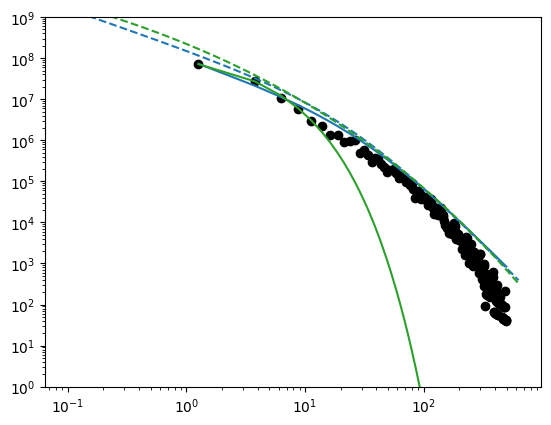

In [147]:
plt.figure()
plt.loglog()
plt.plot(r_fit, rho_nfw, c='C0', ls='--')
plt.plot(r_halo, rho_nfw_fit, c='C0')

plt.plot(r_fit, rho_einasto, c='C2', ls='--')
plt.plot(r_halo, rho_einasto_fit, c='C2')

plt.scatter(r_halo, rho_halo, c='k')
plt.ylim(1e0, 1e9)
#plt.plot(r_halo, rho_einasto, '-', label = 'Einasto');


# Basis computation

In [161]:
einasto_basis = EXPtools.basis.make_basis(
    r_fit, rho_einasto, Mtotal=1, 
    basis_id='sphereSL', Lmax= 6, nmax= 10, rmapping=float(r_halo[-1]/cvir), 
    modelname='einasto_basis_test.txt', cachename='einasto_cache.txt', physical_units=True)

! Scaling: R = 630.957344480193  M = 1
Scaling factors: rfac = 1.0, dfac = 1.0, mfac = 1.0, pfac = 1.0
{'basis_id': 'sphereSL', 'Lmax': 6, 'nmax': 10, 'rmapping': 50.18832479288645, 'modelname': 'einasto_basis_test.txt', 'cachename': 'einasto_cache.txt'}
{'id': 'sphereSL', 'parameters': {'Lmax': 6, 'nmax': 10, 'rmapping': 50.18832479288645, 'modelname': 'einasto_basis_test.txt', 'cachename': 'einasto_cache.txt', 'rmin': 0.1, 'rmax': 630.957, 'numr': 1000}}
---- SLGridSph::WriteH5Cache: wrote <einasto_cache.txt>
---- Spherical::orthoTest: worst=0.000616385


---- SLGridSph::ReadH5Cache: error reading <einasto_cache.txt>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file einasto_cache.txt (File accessibility) Unable to open file>


In [88]:
nfw_basis = EXPtools.basis.make_basis(
    r_halo, rho_nfw, Mtotal=1, 
    basis_id='sphereSL', Lmax= 6, nmax= 30, rmapping=float(r_halo[-1]/cvir), 
    modelname='nfw_basis_test_30.txt', cachename='nfw_cache_30.txt', physical_units=True)

! Scaling: R = 498.743743718593  M = 1
Scaling factors: rfac = 1.0, dfac = 1.0, mfac = 1.0, pfac = 1.0
{'basis_id': 'sphereSL', 'Lmax': 6, 'nmax': 30, 'rmapping': 50.18832479288645, 'modelname': 'nfw_basis_test_30.txt', 'cachename': 'nfw_cache_30.txt'}
{'id': 'sphereSL', 'parameters': {'Lmax': 6, 'nmax': 30, 'rmapping': 50.18832479288645, 'modelname': 'nfw_basis_test_30.txt', 'cachename': 'nfw_cache_30.txt', 'rmin': 1.266256, 'rmax': 498.744, 'numr': 199}}
---- SLGridSph::WriteH5Cache: wrote <nfw_cache_30.txt>
---- Spherical::orthoTest: worst=0.0547327


---- SLGridSph::ReadH5Cache: error reading <nfw_cache_30.txt>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file nfw_cache_30.txt (File accessibility) Unable to open file>


In [21]:
Mvir/1e12

np.float64(1.9865915488057642)

In [22]:
np.sum(np.ones(len(pos))*particle_mass)/1e12

np.float64(1.1632)

In [162]:
einasto_basis_profile = einasto_basis.getBasis(np.log10(r_halo[0]), np.log10(r_halo[-1]), 199)[0][0]['density']
nfw_basis_profile = nfw_basis.getBasis(np.log10(r_halo[0]), np.log10(r_halo[-1]), 199)[0][0]['density']

In [163]:
r_basis = np.logspace(np.log10(r_halo[0]), np.log10(r_halo[-1]), 199)

In [164]:
einasto_model = np.loadtxt("einasto_basis_test.txt", skiprows=3)
nfw_model = np.loadtxt("nfw_basis_test.txt", skiprows=3)

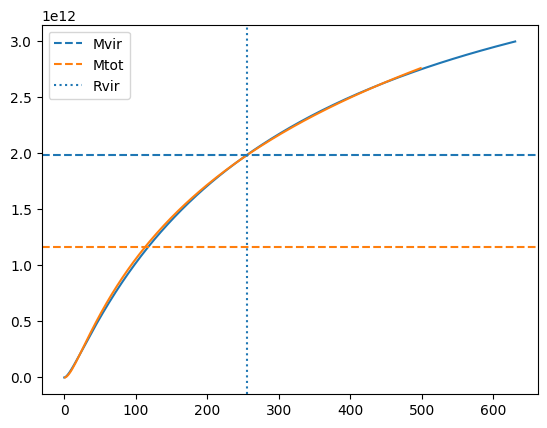

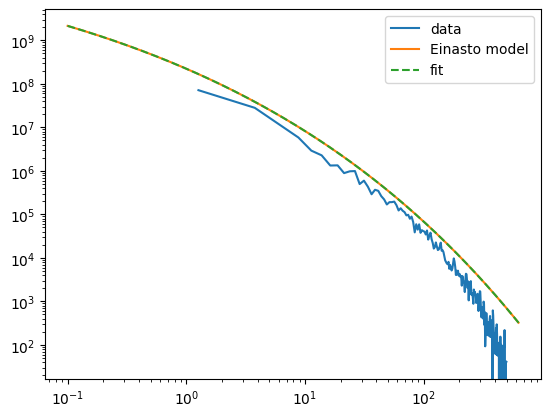

In [166]:
plt.loglog(r_halo, rho_halo, label='data')
plt.loglog(einasto_model[:,0], einasto_model[:,1], label='Einasto model')
plt.loglog(r_fit, rho_einasto, c='C2', ls='--', label='fit')
plt.legend()


# Coefficients computation

In [167]:
gadget_particle_mass = 1e10
units = [('mass', 'Msun', gadget_particle_mass),
         ('length', 'kpc', 1.0),
         ('velocity', 'km/s', 1.0),
         ('G', 'mixed', 43007.1)]


In [168]:
einasto_coef = einasto_basis.createFromArray(mass=np.ones(len(pos))*particle_mass/1e10, pos=pos, time=0.0)
einasto_coefs = pyEXP.coefs.Coefs.makecoefs(einasto_coef, 'halo')
einasto_coefs.setUnits(units)
einasto_coefs.add(einasto_coef)


In [170]:
for i in range(20):
    rho_basis = nfw_basis.getFields(0.01, 2.5, 100)[i][0]['density']
    plt.plot(rho_basis)

TypeError: 'float' object is not subscriptable

In [266]:
nfw_coef = nfw_basis.createFromArray(mass=np.ones(len(pos_host))*particle_mass/gadget_particle_mass, pos=pos_host, time=0.0)
nfw_coefs = pyEXP.coefs.Coefs.makecoefs(nfw_coef, 'halo')
nfw_coefs.setUnits(units)
nfw_coefs.add(nfw_coef)


In [267]:
nfw_f_coef = nfw_basis.createFromArray(mass=np.ones(len(pos_host_fuzz))*particle_mass/gadget_particle_mass, pos=pos_host_fuzz, time=0.0)
nfw_f_coefs = pyEXP.coefs.Coefs.makecoefs(nfw_f_coef, 'halo')
nfw_f_coefs.setUnits(units)
nfw_f_coefs.add(nfw_f_coef)


In [172]:
print(einasto_coefs.getAllCoefs()[0][0])
print(nfw_coefs.getAllCoefs()[0][0])

[38.26292993+0.j]
[38.24604054+0.j]


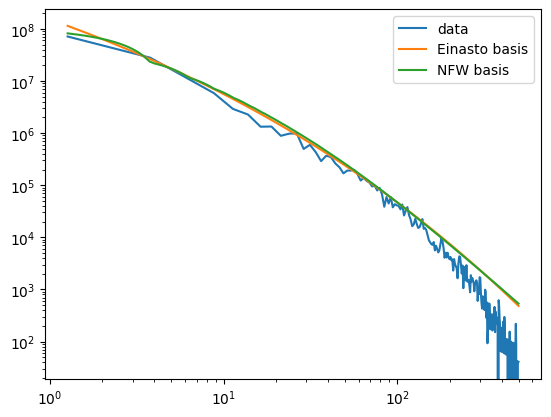

In [173]:
plt.loglog(r_halo, rho_halo, label='data')
plt.plot(r_basis, einasto_basis_profile*38.16*particle_mass, label='Einasto basis')
plt.plot(r_basis, nfw_basis_profile*38.24*particle_mass, label='NFW basis')

#plt.loglog(einasto_model[:,0], einasto_model[:,1], label='Einasto model')
#plt.loglog(nfw_model[:,0], nfw_model[:,1], label='NFW model')

#plt.loglog(r_halo, rgridsho_einasto, c='C2', ls='--', label='fit')
plt.legend()


#### Basis fidelity

In [174]:
import sys
sys.path.append("/home/ngc/Work/research/XMC-Atlas/scripts/validation/")
from metrics import spherical_grid, mise, mirse, kd3_point_density, relative_error

In [188]:
def density_profiles(
    particles_pos,
    particles_mass,
    basis,
    coefs,
    r_edges,
    theta_bins=20,
    phi_bins=40,
    time=0.0,
    k_max=20,
):
    particle_profile = np.zeros(len(r_edges))
    bfe_profile = np.zeros(len(r_edges))
    for i, r in enumerate(r_edges):
        xyz = spherical_grid(
            {"theta_bins": theta_bins, "phi_bins": phi_bins},
            r
        )

        fg = pyEXP.field.FieldGenerator([time], xyz)
        dens_bfe = fg.points(basis, coefs)[time]["dens"]
        dens_part = kd3_point_density(
            particles_pos,
            particles_mass,
            xyz,
            k_max=k_max
        )
        bfe_profile[i] = np.median(dens_bfe)
        particle_profile[i] = np.median(dens_part)
    return bfe_profile, particle_profile

In [245]:
rho_bfe_einasto_r, rho_part_r = density_profiles(pos_host, np.ones(len(pos_host))*particle_mass/gadget_particle_mass, 
                                           einasto_basis, einasto_coefs, r_halo)

In [248]:
rho_bfe_nfw_r, rho_part_r = density_profiles(pos_host, np.ones(len(pos_host))*particle_mass/gadget_particle_mass, 
                                           nfw_basis, nfw_coefs, r_halo)

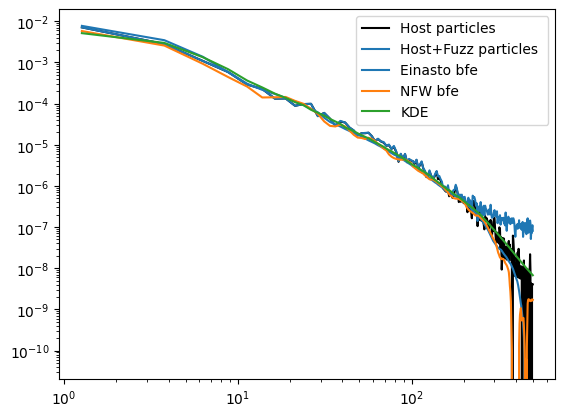

In [249]:
plt.loglog(r_halo, rho_host/gadget_particle_mass, label='Host particles', c='k')
plt.loglog(r_halo, rho_host_fuzz/gadget_particle_mass, label='Host+Fuzz particles ', c='C0')
plt.loglog(r_halo, rho_bfe_einasto_r, label='Einasto bfe')
plt.loglog(r_halo, rho_bfe_nfw_r, label='NFW bfe')
plt.loglog(r_halo, rho_part_r, label='KDE')
plt.legend()

In [250]:

def radial_mise_mirse(
    particles_pos,
    particles_mass,
    basis,
    coefs,
    r_edges,
    theta_bins=20,
    phi_bins=40,
    time=0.0,
    k_max=200,
):
    """
    Compute radially binned MISE and MIRSE for a spherical 3D distribution.

    """

    mise_r = np.zeros(len(r_edges))
    mirse_r = np.zeros(len(r_edges))
    relative_error_r = np.zeros(len(r_edges))

    for i, r in enumerate(r_edges):
        xyz = spherical_grid(
            {"theta_bins": theta_bins, "phi_bins": phi_bins},
            r
        )

        fg = pyEXP.field.FieldGenerator([time], xyz)
        dens_bfe = fg.points(basis, coefs)[time]["dens"]

        dens_part = kd3_point_density(
            particles_pos,
            particles_mass,
            xyz,
            k_max=k_max
        )

        mise_r[i] = mise(dens_bfe, dens_part)
        mirse_r[i] = mirse(dens_bfe, dens_part)
        relative_error_r[i] = np.mean(relative_error(dens_bfe, dens_part))
        

    return r_edges, mise_r, mirse_r, relative_error_r


In [252]:
rbins, nfw_mise_r, nfw_mirse_r, nfw_re_r = radial_mise_mirse(pos_host, np.ones(len(pos_host))*particle_mass/gadget_particle_mass, 
                                                             nfw_basis, nfw_coefs, r_halo)


In [268]:
rbins, nfw_f_mise_r, nfw_f_mirse_r, nfw_f_re_r = radial_mise_mirse(pos_host_fuzz, np.ones(len(pos_host_fuzz))*particle_mass/gadget_particle_mass, 
                                                             nfw_basis, nfw_f_coefs, r_halo)


In [254]:
rbins, ein_mise_r, ein_mirse_r, ein_re_r = radial_mise_mirse(pos_host, np.ones(len(pos_host))*particle_mass/gadget_particle_mass, 
                                                             einasto_basis, einasto_coefs, r_halo)

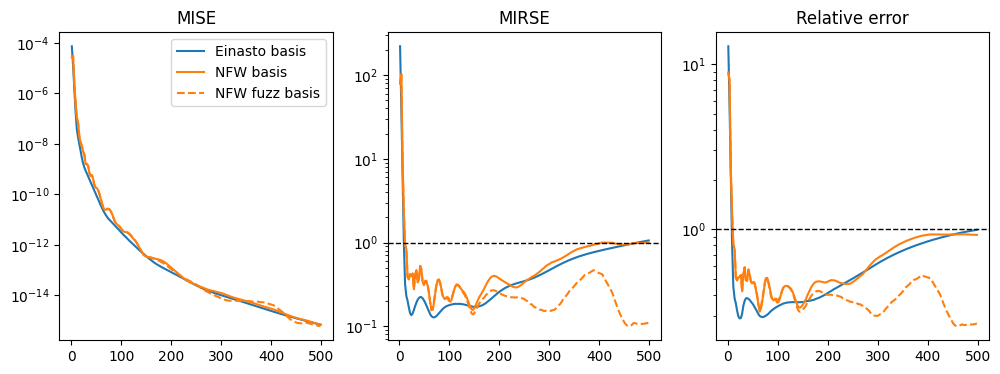

In [269]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].semilogy(rbins, ein_mise_r, c='C0', label='Einasto basis')
ax[1].semilogy(rbins, ein_mirse_r, c='C0')
ax[2].semilogy(rbins, ein_re_r, c='C0')


ax[0].semilogy(rbins, nfw_mise_r, c='C1', label='NFW basis')
ax[1].semilogy(rbins, nfw_mirse_r, c='C1')
ax[2].semilogy(rbins, nfw_re_r, c='C1')

ax[0].semilogy(rbins, nfw_f_mise_r, c='C1', label='NFW fuzz basis', ls='--')
ax[1].semilogy(rbins, nfw_f_mirse_r, c='C1', ls='--')
ax[2].semilogy(rbins, nfw_f_re_r, c='C1', ls='--')

ax[0].set_title('MISE')
ax[1].set_title('MIRSE')
ax[2].set_title('Relative error')
ax[1].axhline(1, lw=1, c='k', ls='--')
ax[2].axhline(1, lw=1, c='k', ls='--')

ax[0].legend()


In [100]:
def project_density_along_axis(
    xyz,
    rho,
    axis="z",
    bins=200,
    range=None,
):

    xyz = np.asarray(xyz)
    rho = np.asarray(rho)

    if axis == "z":
        X, Y = xyz[:, 0], xyz[:, 1]
    elif axis == "y":
        X, Y = xyz[:, 0], xyz[:, 2]
    elif axis == "x":
        X, Y = xyz[:, 1], xyz[:, 2]
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    # Line-of-sight integration: sum density
    Sigma, xedges, yedges = np.histogram2d(
        X,
        Y,
        bins=bins,
        range=range,
        weights=rho,GroupVel', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', '│

    )

    # Number of contributing samples
    counts, _, _ = np.histogram2d(
        X,
        Y,
        bins=[xedges, yedges],
    )

    return Sigma, counts, xedges, yedges


In [ ]:
# density profile.`

In [ ]:
# 2d density profile

In [ ]:
xyz_3d_grid = np.zeros((100, 20, 40))
rho_bfe_3d_grid = np.zeros((100, 20, 40))
rho_particle_3d_grid = np.zeros((100, 20, 40))
for i, r in enumerate(r_halo):
    xyz_3d_grid[i] = spherical_grid({"theta_bins": theta_bins, "phi_bins": phi_bins}, r_shell)
        
    fg = pyEXP.field.FieldGenerator([time], xyz)
    dens_bfe = fg.points(basis, coefs)[time]["dens"]*particle_mass

    dens_part = kd3_point_density(
        particles_pos,
        particles_mass,
        xyz,
        k_max=k_max
    )

In [ ]:
# gof, MISE

In [197]:
# Fields

In [ ]:
fields = pyEXP.field.FieldGenerator(times, pmin, pmax, grid)

surfaces = fields.slices(basis, coefs)

print("We now have the following [time field] pairs")
for v in surfaces:
    print('-'*40)
    for u in surfaces[v]:
        print("{:8.4f}  {}".format(v, u))

print("\nHere is the first one:")
for v in surfaces:
    for u in surfaces[v]:
        print('-'*40)
        print('----', u)
        print('-'*40)
        print(surfaces[v][u])
    break